this code is dependent on https://github.com/OutofAi/2D-Gaussian-Splatting/blob/main/2D_Gaussian_Splatting.ipynb

OutofAi/2D-Gaussian-Splatting repository

In [69]:
# load dependency
import numpy as np
import torch
import torch.nn.functional as F
from torch.optim.lr_scheduler import LinearLR
import torch.nn as nn
import gc # garbage collector, prevent memory leak
import os
import imageio
import yaml
from torch.optim import Adam
from datetime import datetime
from PIL import Image
import requests

import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

In [66]:
device = "cuda"
kernel_size = 101

scale_x = torch.tensor([1.0, 0.5, 0.5], device=device)
scale_y = torch.tensor([1.0, 0.5, 1.5], device=device)
scale = torch.stack([scale_x, scale_y], dim=-1) # (N, 2)
rotation = torch.tensor([0.5, 0.0, -0.5], device=device) # between -pi/2 and pi/2 (1.57)
means = torch.tensor([(-0.5, -0.5), (0.8, 0.8), (0.5, 0.5)], device=device)
colors = torch.tensor([(1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (0.0, 0.0, 1.0)], device=device)
HEIGHT = 105
WIDTH = 105
img_size = (HEIGHT, WIDTH, 3)
X_RANGE = 5.0 # range (-X_RANGE, X_RANGE)
Y_RANGE = 5.0 # range (-Y_RANGE, Y_RANGE)

batch_size = colors.shape[1]

In [68]:
# generate 2D Gaussian Splatting

# compute covariance component
sin = torch.sin(rotation)
cos = torch.cos(rotation)
R = torch.stack([
    torch.stack([cos, -sin], dim=-1),
    torch.stack([sin, cos], dim=-1)], dim=-2) # (N, 2, 2)
S = torch.diag_embed(scale)

# compute covariance
covariance = R @ S @ S @ R.transpose(-1, -2)
inv_covariance = torch.inverse(covariance)

# create the kernel
x = torch.linspace(-X_RANGE, X_RANGE, kernel_size, device=device)
y = torch.linspace(-Y_RANGE, Y_RANGE, kernel_size, device=device)
xx, yy = torch.meshgrid(x, y, indexing='ij')
xy = torch.stack([xx, yy], dim=-1) # (kernel_size, kernel_size, 2)
xy = xy.unsqueeze(0).expand(batch_size, -1, -1, -1) # (N, kernel_size, kernel_size, 2)

z = torch.einsum('bxyi, bij, bxyj -> bxy', xy, -0.5*inv_covariance, xy)
kernel = torch.exp(z) / (2 * torch.tensor(torch.pi, device=device) * torch.sqrt(torch.det(covariance))).view(batch_size, 1, 1) # (batch_size, kernel_size, kernel_size)

# normalize the kernel
kernel_max = kernel.amax(dim=(-2, -1), keepdim=True)
kernel_normalized = kernel / kernel_max

# reshape the kernel for RGB channel
kernel_rgb = kernel_normalized.unsqueeze(1).expand(-1, 3, -1, -1)

# add padding to mathc image size
pad_h = img_size[0]- kernel_size
pad_w = img_size[1]- kernel_size

if pad_h < 0 or pad_w < 0:
    raise ValueError("kernel size must be smaller than image size")

padding = (pad_w//2, pad_w//2 + pad_w%2, pad_h//2, pad_h//2 + pad_h%2)
kernel_rgb_padded = F.pad(kernel_rgb, padding, "constant", 0)

# Translate the kernel
b, c, h, w = kernel_rgb_padded.shape
theta = torch.zeros(b, 2, 3, dtype=torch.float32, device=device)
theta[:, 0, 0] = 1.0
theta[:, 1, 1] = 1.0
theta[:, :, 2] = means

grid = F.affine_grid(theta, size=(b, c, h, w), align_corners=True)
kernel_rgb_padded_translated = F.grid_sample(kernel_rgb_padded, grid, align_corners=True)

# Apply colors and sum the layers
rgb_values_reshape = colors.unsqueeze(-1).unsqueeze(-1)
final_image_layers = rgb_values_reshape * kernel_rgb_padded_translated
final_image = final_image_layers.sum(dim=0)
final_image = torch.clamp(final_image, 0, 1)
final_image = final_image.permute(1, 2, 0)




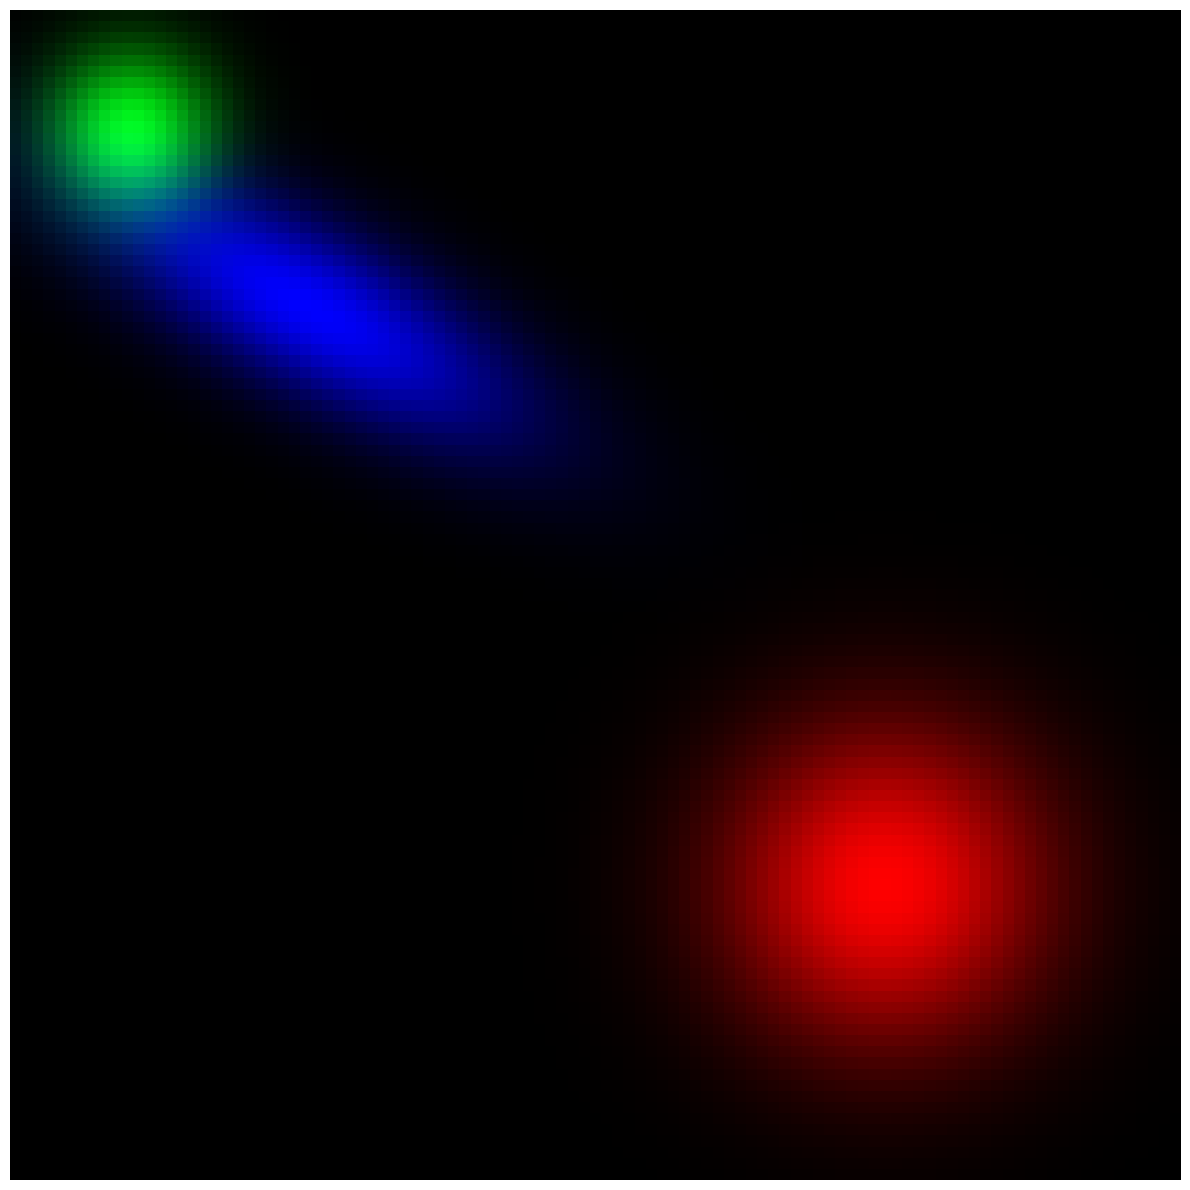

In [70]:
plt.imshow(final_image.detach().cpu().numpy())
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def create_window(window_size, channel):
    def gaussian(window_size, sigma):
        gauss = torch.exp(torch.tensor([-(x - window_size//2)**2/float(2*sigma**2) for x in range(window_size)]))
        return gauss/gauss.sum()
    
    _1D_window = gaussian(window_size, 1.5).unsqueeze(1)
    _2D_window = _1D_window.mm(_1D_window.t()).float.unsqueeze(0).unsqueeze(0)
    window = torch.autograd.Variable(_2D_window.expand(channel, 1, window_size, window_size).contiguous())

    return window  # shape: [channel, 1, window_size, window_size]

def ssim(img1, img2, window_size=11, size_average=True):
    
    (_, _, channel) = img1.size()
    
    img1 = img1.unsqueeze(0).permute(0,3,1,2) # (1, channel, height, width) maybe
    img2 = img2.unsqueeze(0).permute(0,3,1,2)
    
    # Parameters for SSIM
    C1 = 0.01**2
    C2 = 0.03**2
    
    window = create_window(window_size, channel)
    
    if img1.is_cuda:
        window = window.cuda(img1.get_device())
    window = window.type_as(img1)
    
    